# TRABALHO IAA002 - Linguagem de Pogramação Aplicada

---
#### Importação das Bibliotecas

In [95]:
# Importação das bibliotecas para Manipulação de Dados e Criação de Gráficos:
# Panda, Seaborn e Matplotlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Importação da biblioteca para ignorar mensagens de warning ao rodar uma célula do código
import warnings
warnings.filterwarnings('ignore')


In [96]:
# Importação das bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

# Importando métricas de avaliação dos modelos
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

---
### 1. Análise Exploratória dos dados

#### a. Importação dos dados

In [97]:
dados=pd.read_csv('precos_carros_brasil.csv')

In [98]:
# Consultado o nome das colunas
dados.columns

Index(['year_of_reference', 'month_of_reference', 'fipe_code',
       'authentication', 'brand', 'model', 'fuel', 'gear', 'engine_size',
       'year_model', 'avg_price_brl'],
      dtype='str')

In [99]:
# Vou gerar as primeiras 5 linhas da tabela para visualização
dados.head()

,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl
0,2021.0,January,004001-0,cfzlctzfwrcp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2002.0,9162.0
1,2021.0,January,004001-0,cdqwxwpw3y2p,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2001.0,8832.0
2,2021.0,January,004001-0,cb1t3xwwj1xp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2000.0,8388.0
3,2021.0,January,004001-0,cb9gct6j65r0,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Alcohol,manual,1,2000.0,8453.0
4,2021.0,January,004003-7,g15wg0gbz1fx,GM - Chevrolet,Corsa Pick-Up GL/ Champ 1.6 MPFI / EFI,Gasoline,manual,"1,6",2001.0,12525.0


In [100]:
dados.shape

(267542, 11)

In [101]:
# Irei traduzir para o português as colunas dos dados
dados=dados.rename(columns={
    'year_of_reference': 'ano_de_referencia',
    'year_model':        'ano_modelo',
    'avg_price_brl':     'preco_medio_brl',
    'month_of_reference':'mes_de_referencia',
    'fipe_code':         'codigo_fipe',
    'authentication':    'autenticacao',
    'brand':             'marca',
    'model':             'modelo',
    'fuel':              'combustivel',
    'gear':              'cambio',
    'engine_size':       'tamanho_motor'
})

##### Resumo dos dados: 267.542 linhas e 11 colunas

#### b. Verificação de valores faltantes

In [102]:
# Antes de verificar valores faltantes, irei confirmar quais são os tipos de dados de cada coluna
# str = variáveis categóricas
# float = variáveis numéricas
dados.dtypes

ano_de_referencia    float64
mes_de_referencia        str
codigo_fipe              str
autenticacao             str
marca                    str
modelo                   str
combustivel              str
cambio                   str
tamanho_motor            str
ano_modelo           float64
preco_medio_brl      float64
dtype: object

In [103]:
# Agora, irei verificar se há valores faltantes na minha base de dados
dados.isna().any()

ano_de_referencia    True
mes_de_referencia    True
codigo_fipe          True
autenticacao         True
marca                True
modelo               True
combustivel          True
cambio               True
tamanho_motor        True
ano_modelo           True
preco_medio_brl      True
dtype: bool

In [104]:
# Verifiquei que há valores faltantes em todas as colunas da base de dados
# Agora irei verificar quantos valores estão faltantes em cada coluna
dados.isna().sum()


ano_de_referencia    65245
mes_de_referencia    65245
codigo_fipe          65245
autenticacao         65245
marca                65245
modelo               65245
combustivel          65245
cambio               65245
tamanho_motor        65245
ano_modelo           65245
preco_medio_brl      65245
dtype: int64

In [105]:
# Agora que já verifiquei a quantidade de dados faltantes
# irei preencher esses valores com o termo "Null"
## Para variáveis STR
dados[['mes_de_referencia', 'codigo_fipe', 'autenticacao', 'marca', 'modelo', 'combustivel', 'cambio', 'tamanho_motor']] = \
dados[['mes_de_referencia', 'codigo_fipe', 'autenticacao', 'marca', 'modelo', 'combustivel', 'cambio', 'tamanho_motor']].replace(['', None], 'Não informado')

In [106]:
dados.isna().sum()

ano_de_referencia    65245
mes_de_referencia        0
codigo_fipe              0
autenticacao             0
marca                    0
modelo                   0
combustivel              0
cambio                   0
tamanho_motor            0
ano_modelo           65245
preco_medio_brl      65245
dtype: int64

In [107]:
(dados[['ano_de_referencia', 'ano_modelo', 'preco_medio_brl']] == 0).sum()

ano_de_referencia    0
ano_modelo           0
preco_medio_brl      0
dtype: int64

In [108]:
# Com essas tratativas chegamos à seguinte conclusão
# Todos os valores vázios STR foram transformados em  'Não Informados'

# Valores ausentes (NaN) foram mantidos nas variáveis numéricas, pois representam ausência de informação. 
## O pandas ignora esses valores automaticamente em cálculos estatísticos, 
### evitando distorções que poderiam ocorrer caso fossem substituídos por zero.

#### c. Verificação de valores duplicados

In [109]:
# Para verificar os valores duplicados, irei usar a função
dados.duplicated().sum()

np.int64(65246)

In [110]:
# Verificando a quantidade de dados duplicados
dados.shape

(267542, 11)

In [111]:
# Removendo os dados duplicados
dados.drop_duplicates(inplace=True)

In [112]:
# Visualizando os dados, após a remoção
dados.shape

(202296, 11)

In [113]:
dados.notnull().sum()

ano_de_referencia    202295
mes_de_referencia    202296
codigo_fipe          202296
autenticacao         202296
marca                202296
modelo               202296
combustivel          202296
cambio               202296
tamanho_motor        202296
ano_modelo           202295
preco_medio_brl      202295
dtype: int64

#### d. Separando valores numéricos e categóricos

In [114]:
# Agora irei criar duas variáveis para analisar separadamente os valores numéricos dos valores categóricos
numericas_cols=[col for col in dados.columns if dados[col].dtype != 'str']
categoricas_cols=[col for col in dados.columns if dados[col].dtype == 'str']

In [115]:
dados[numericas_cols].describe()

,ano_de_referencia,ano_modelo,preco_medio_brl
count,202295.000000,202295.000000,202295.000000
mean,2021.564695,2011.271514,52756.765713
std,0.571904,6.376241,51628.912116
min,2021.000000,2000.000000,6647.000000
25%,2021.000000,2006.000000,22855.000000
50%,2022.000000,2012.000000,38027.000000
75%,2022.000000,2016.000000,64064.000000
max,2023.000000,2023.000000,979358.000000


In [116]:
dados[categoricas_cols].describe()

,mes_de_referencia,codigo_fipe,autenticacao,marca,modelo,combustivel,cambio,tamanho_motor
count,202296,202296,202296,202296,202296,202296,202296,202296
unique,13,2092,202296,7,2113,4,3,30
top,January,001216-5,cfzlctzfwrcp,Fiat,Palio Week. Adv/Adv TRYON 1.8 mpi Flex,Gasoline,manual,"1,6"
freq,24260,425,1,44962,425,168684,161883,47420


#### e. Contagem de valores por modelo e marca do carro

In [117]:
dados['marca'].value_counts()

marca
Fiat               44962
VW - VolksWagen    44312
GM - Chevrolet     38590
Ford               33150
Renault            29191
Nissan             12090
Não informado          1
Name: count, dtype: int64

In [118]:
dados['modelo'].value_counts()

modelo
Palio Week. Adv/Adv TRYON 1.8 mpi Flex    425
Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p     425
Focus 2.0 16V/SE/SE Plus Flex 5p Aut.     400
Saveiro 1.6 Mi/ 1.6 Mi Total Flex 8V      400
Corvette 5.7/ 6.0, 6.2 Targa/Stingray     375
                                         ... 
Saveiro Robust 1.6 Total Flex 16V CD        2
Saveiro Robust 1.6 Total Flex 16V           2
Gol Last Edition 1.0 Flex 12V 5p            2
Polo Track 1.0 Flex 12V 5p                  2
Não informado                               1
Name: count, Length: 2113, dtype: int64

#### f. Conclusão

##### Durante a análise exploratória dos dados, identifiquei 65.246 valores faltantes na base, sendo realizadas tratativas de substituição e exclusão dos registros desnecessários para este trabalho.
##### A base é composta majoritariamente por veículos a gasolina com câmbio manual, e o modelo mais recorrente é o "Palio Week", da marca Fiat, que também é a marca mais presente no dataset.

---
### 2. Visualização dos dados

#### a. Gráfico da distribuição da quantidade de carros por marca

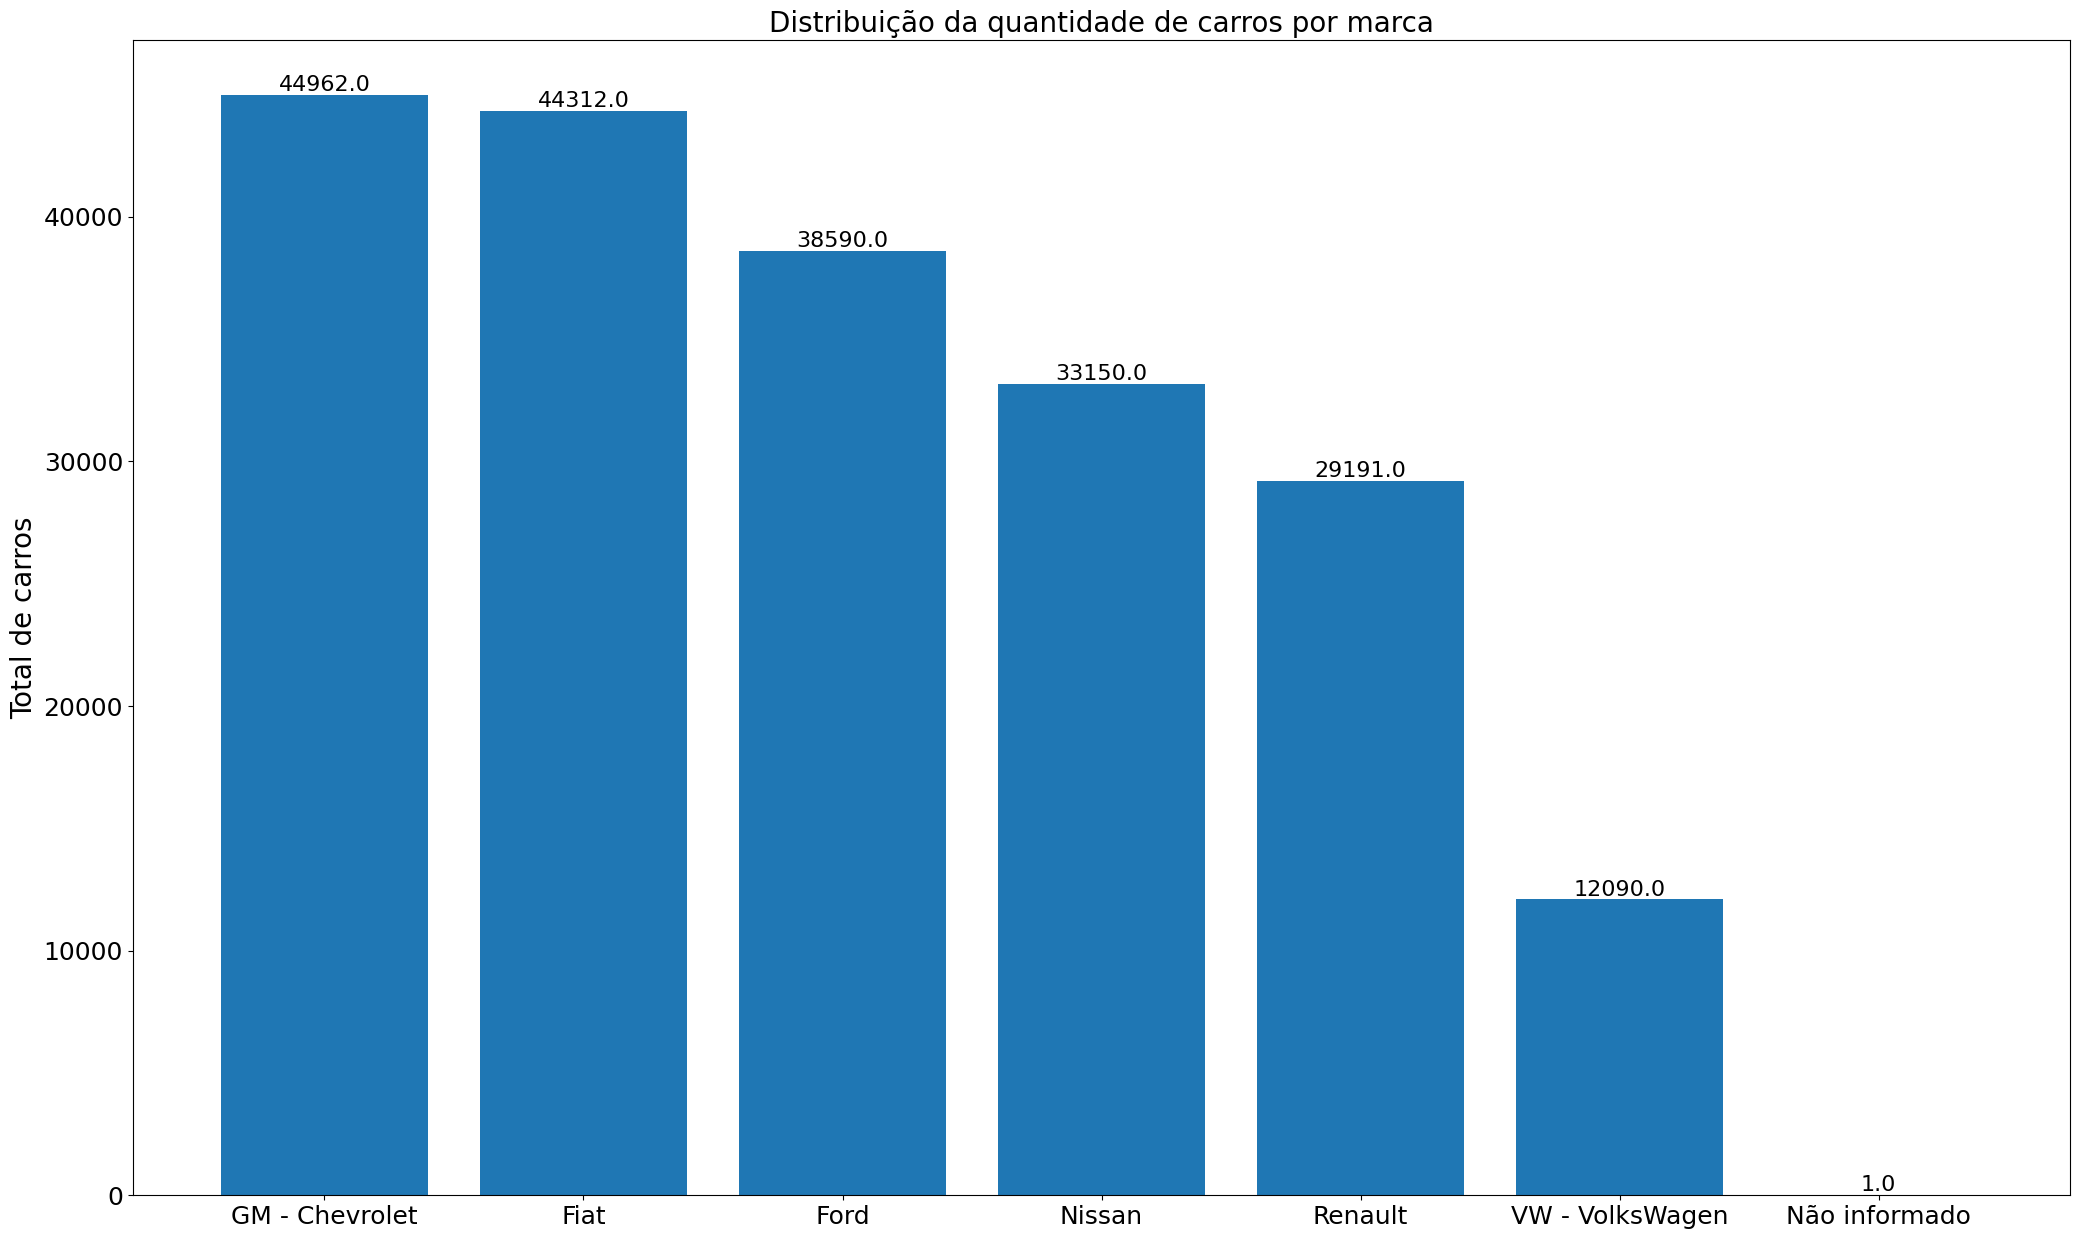

In [119]:
plt.figure(figsize=(25,15)) # Mudando as dimensões do gráfico para 25 por 15
grafico_a=plt.bar(dados['marca'].unique(), dados['marca'].value_counts()) # plt.bar = gráfico de barra
plt.title('Distribuição da quantidade de carros por marca', fontsize=20) #plt.title para inserir um titulo horizontal no gráfico
plt.ylabel('Total de carros', fontsize=20) # plt.title para inserir um titulo vertical no gráfico

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.bar_label(grafico_a, fmt='%.01f', size=16, label_type='edge');

#### b. Gráfico da distribuição da quantidade de carros por tipo de engrenagem do carro

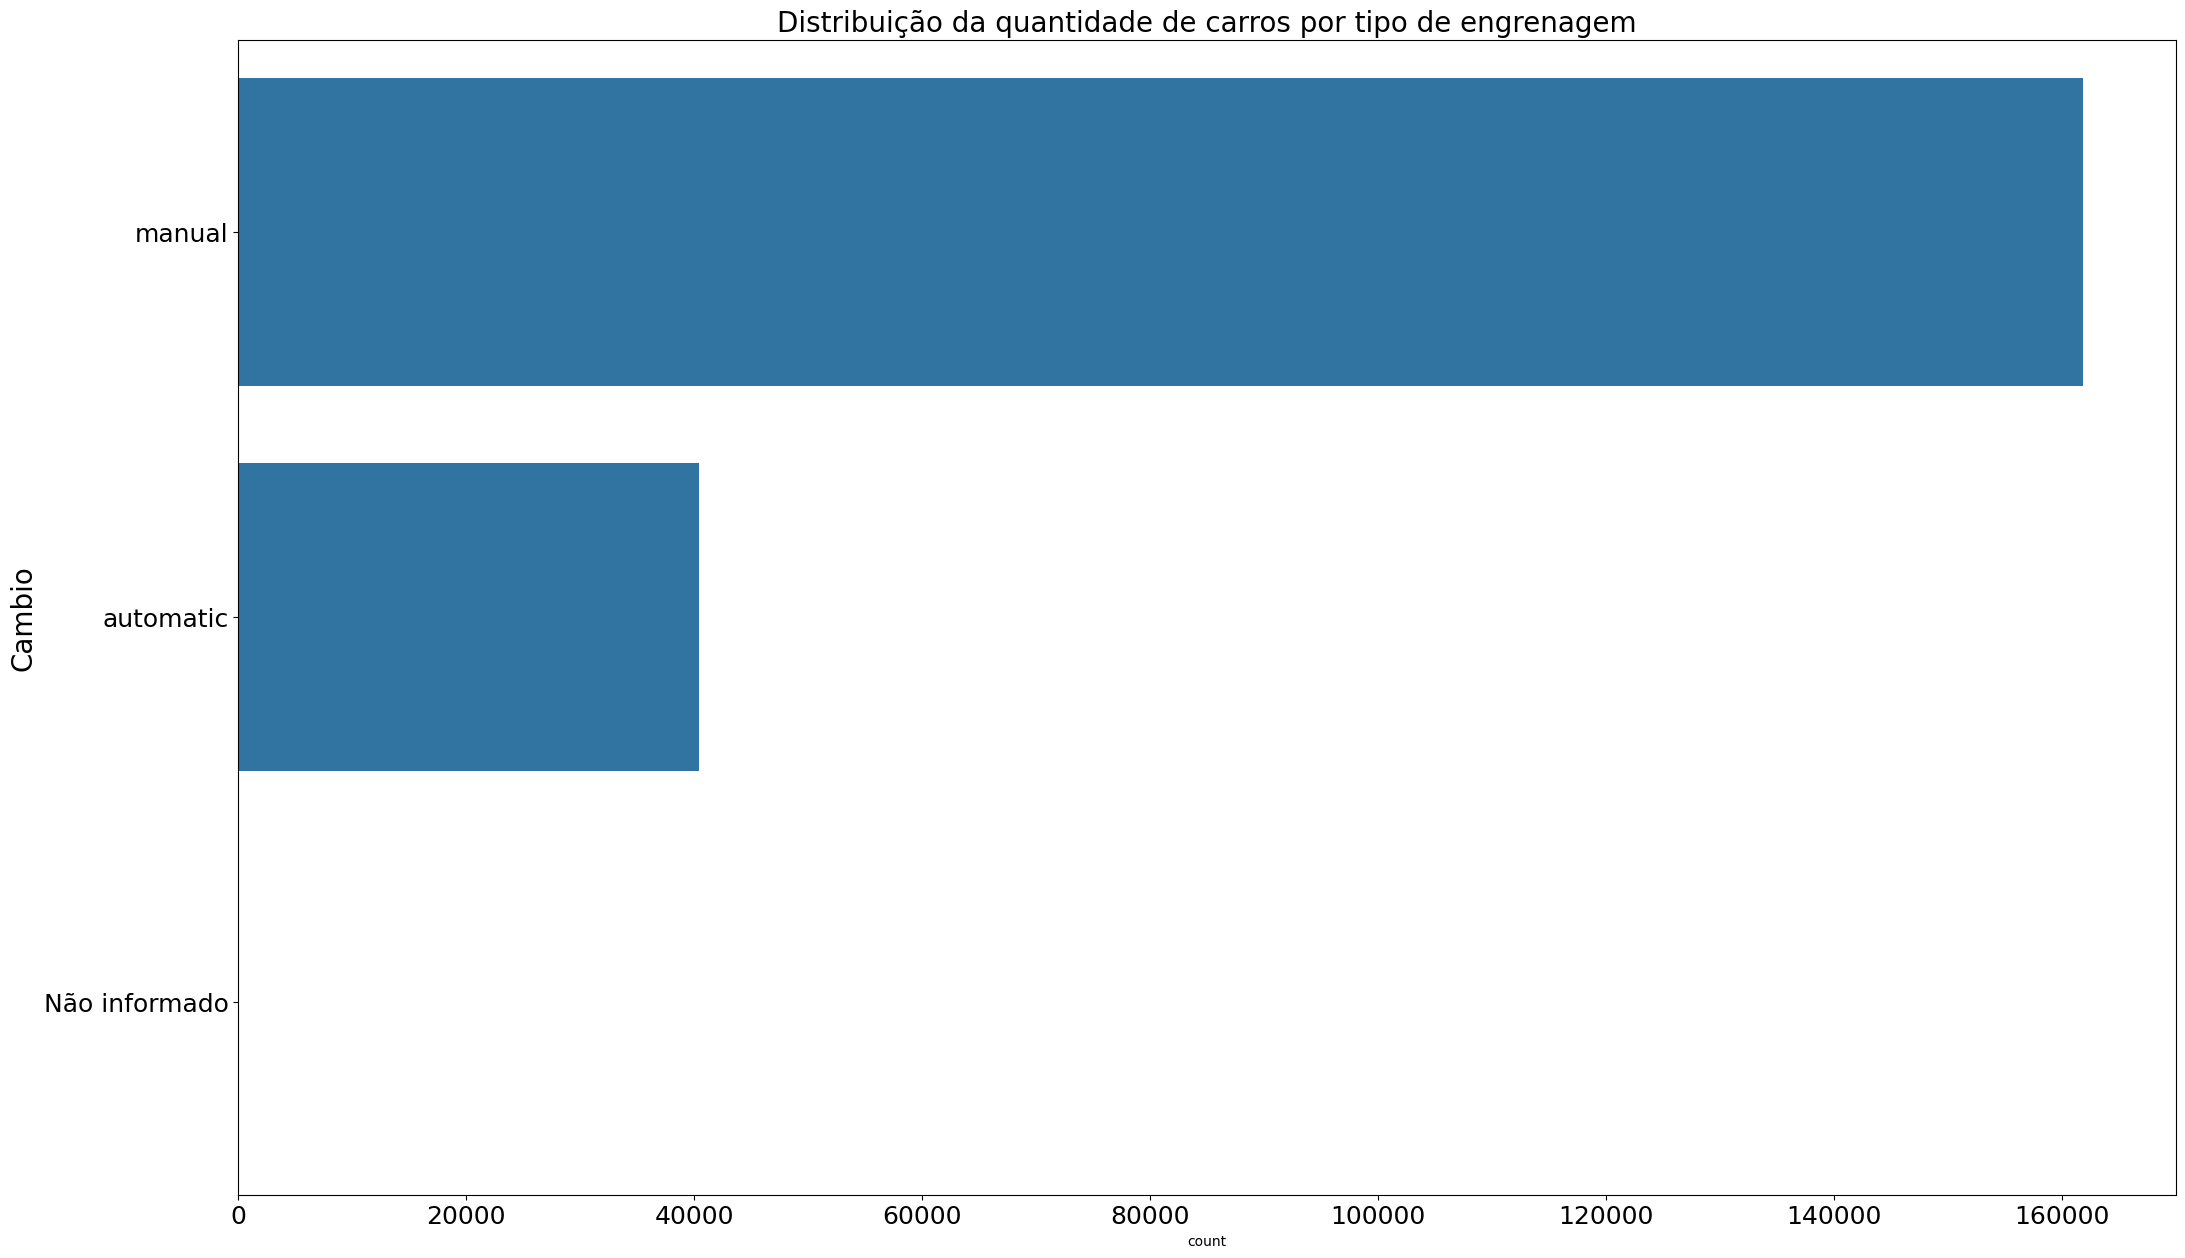

In [120]:
plt.figure(figsize=(25,15))
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.ylabel('Cambio', fontsize=20)
sns.countplot(y='cambio', data=dados, order=dados ['cambio'].value_counts().index)\
.set_title('Distribuição da quantidade de carros por tipo de engrenagem', fontsize=20);

#### c. Gráfico da evolução da média de preços ao longo dos meses

In [121]:
# Verificando as tipos de dados para fazer possíveis alterações
dados.dtypes

ano_de_referencia    float64
mes_de_referencia        str
codigo_fipe              str
autenticacao             str
marca                    str
modelo                   str
combustivel              str
cambio                   str
tamanho_motor            str
ano_modelo           float64
preco_medio_brl      float64
dtype: object

In [122]:
# Agora irei organizar os dados e calcular a média de preço por mês
media_preco_mes=dados[dados['ano_de_referencia']==2022].groupby('mes_de_referencia')['preco_medio_brl'].mean().reset_index()

In [123]:
# Fazendo o ordenamento correto dos meses
ordem_meses = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

media_preco_mes['mes_de_referencia'] = pd.Categorical(
    media_preco_mes['mes_de_referencia'], 
    categories=ordem_meses, 
    ordered=True
)

media_preco_mes = media_preco_mes.sort_values('mes_de_referencia')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

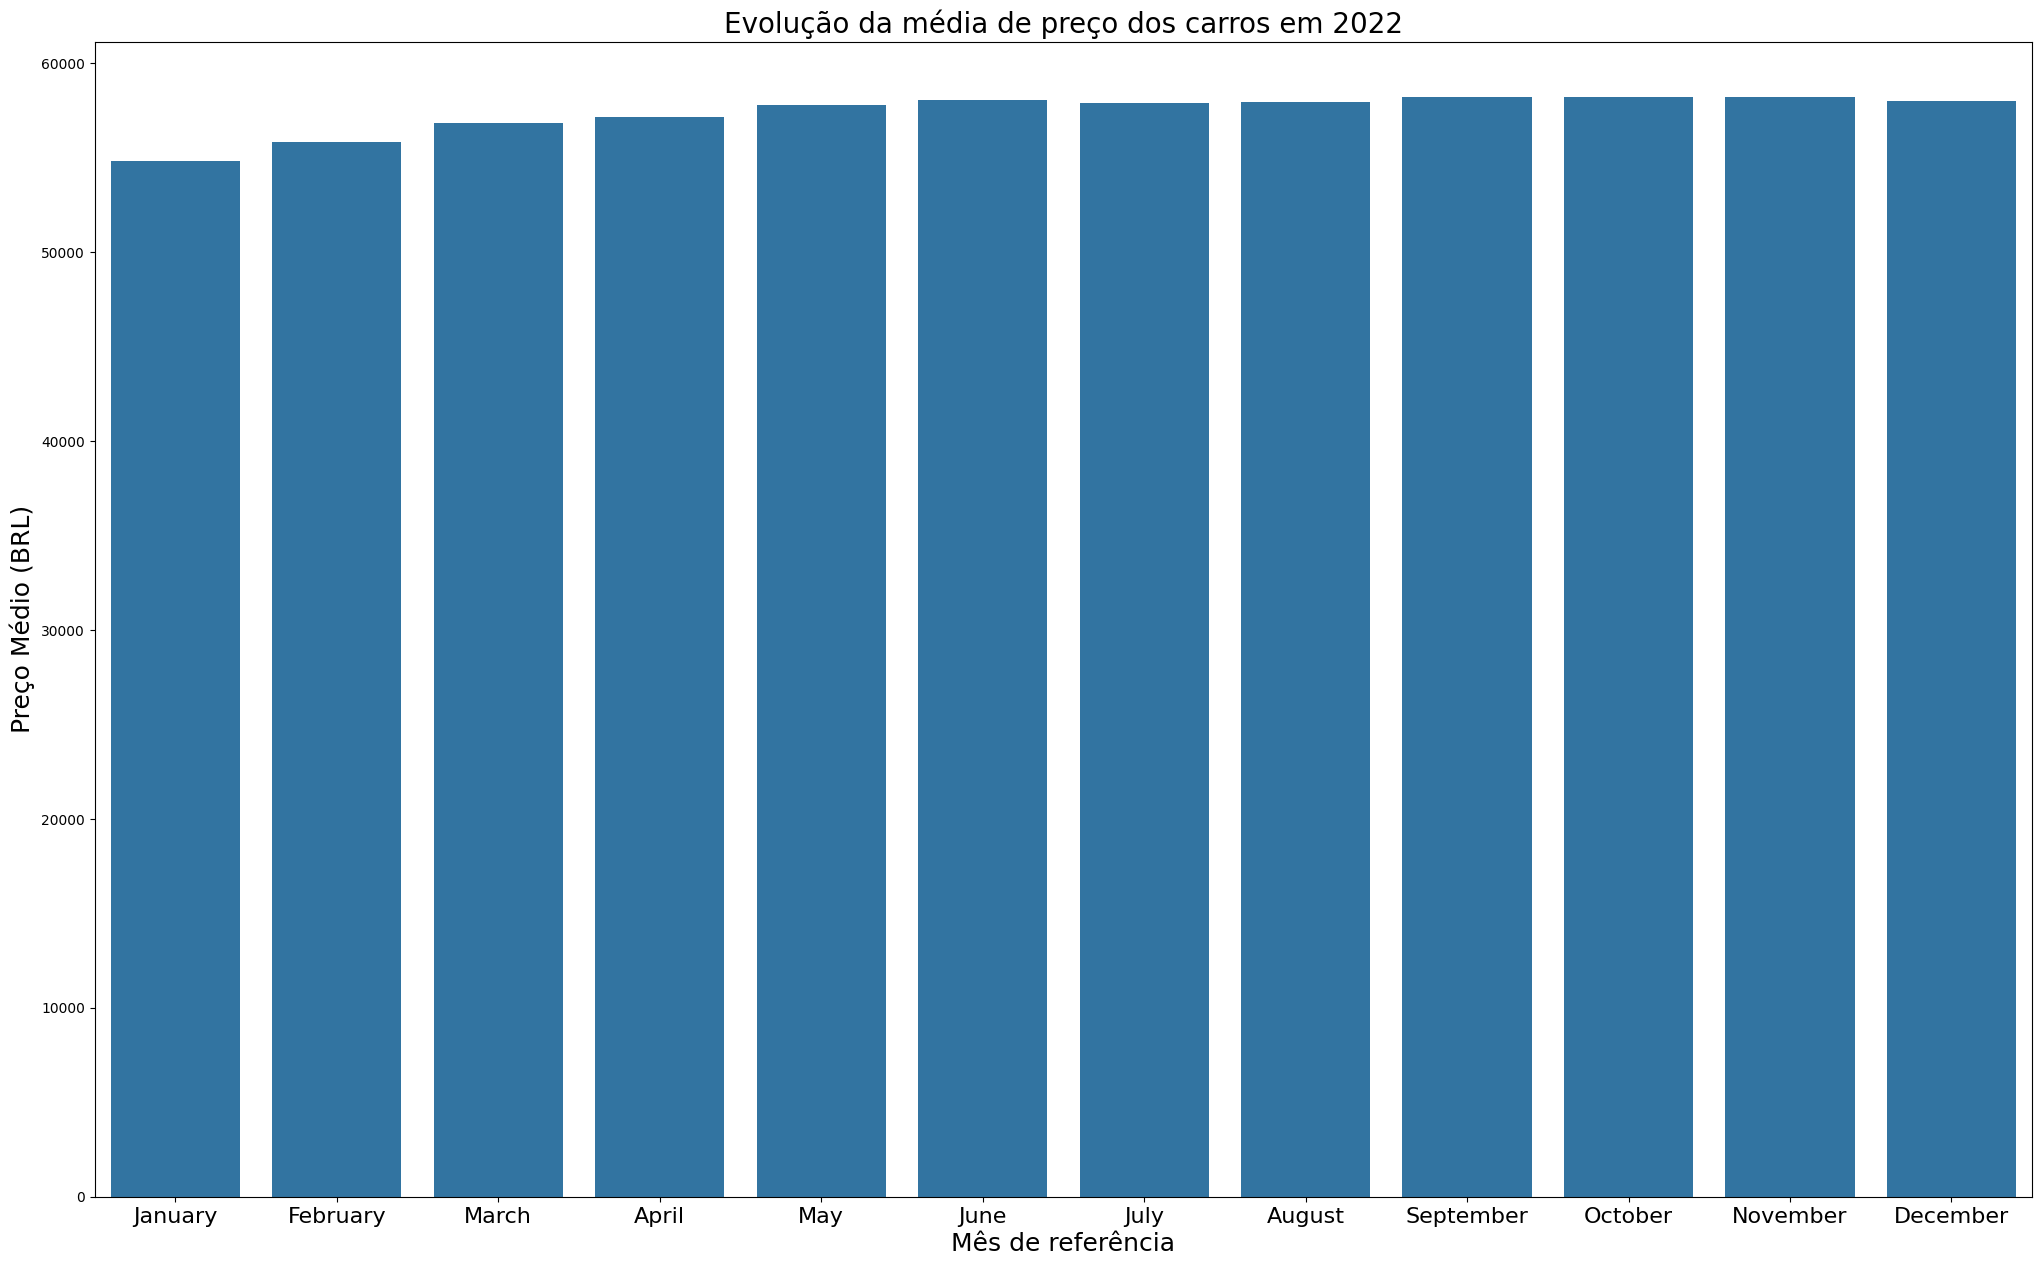

In [124]:
# Criando o gráfico
plt.figure(figsize=(25,15))
sns.barplot(x='mes_de_referencia', y='preco_medio_brl', data=media_preco_mes)

plt.title('Evolução da média de preço dos carros em 2022', fontsize=20)
plt.xlabel('Mês de referência', fontsize=18)
plt.ylabel('Preço Médio (BRL)', fontsize=18)

plt.xticks(fontsize=16)
plt.xticks(fontsize=16)

#### d. Gráfico da distribuição da média de preços dos carros por marca e tipo de engrenagem

In [125]:
# Organizando os dados para calcular a média de preços por marca e câmbio
media_preco_marca_cambio=dados.groupby(['marca', 'cambio'])['preco_medio_brl'].mean().reset_index()

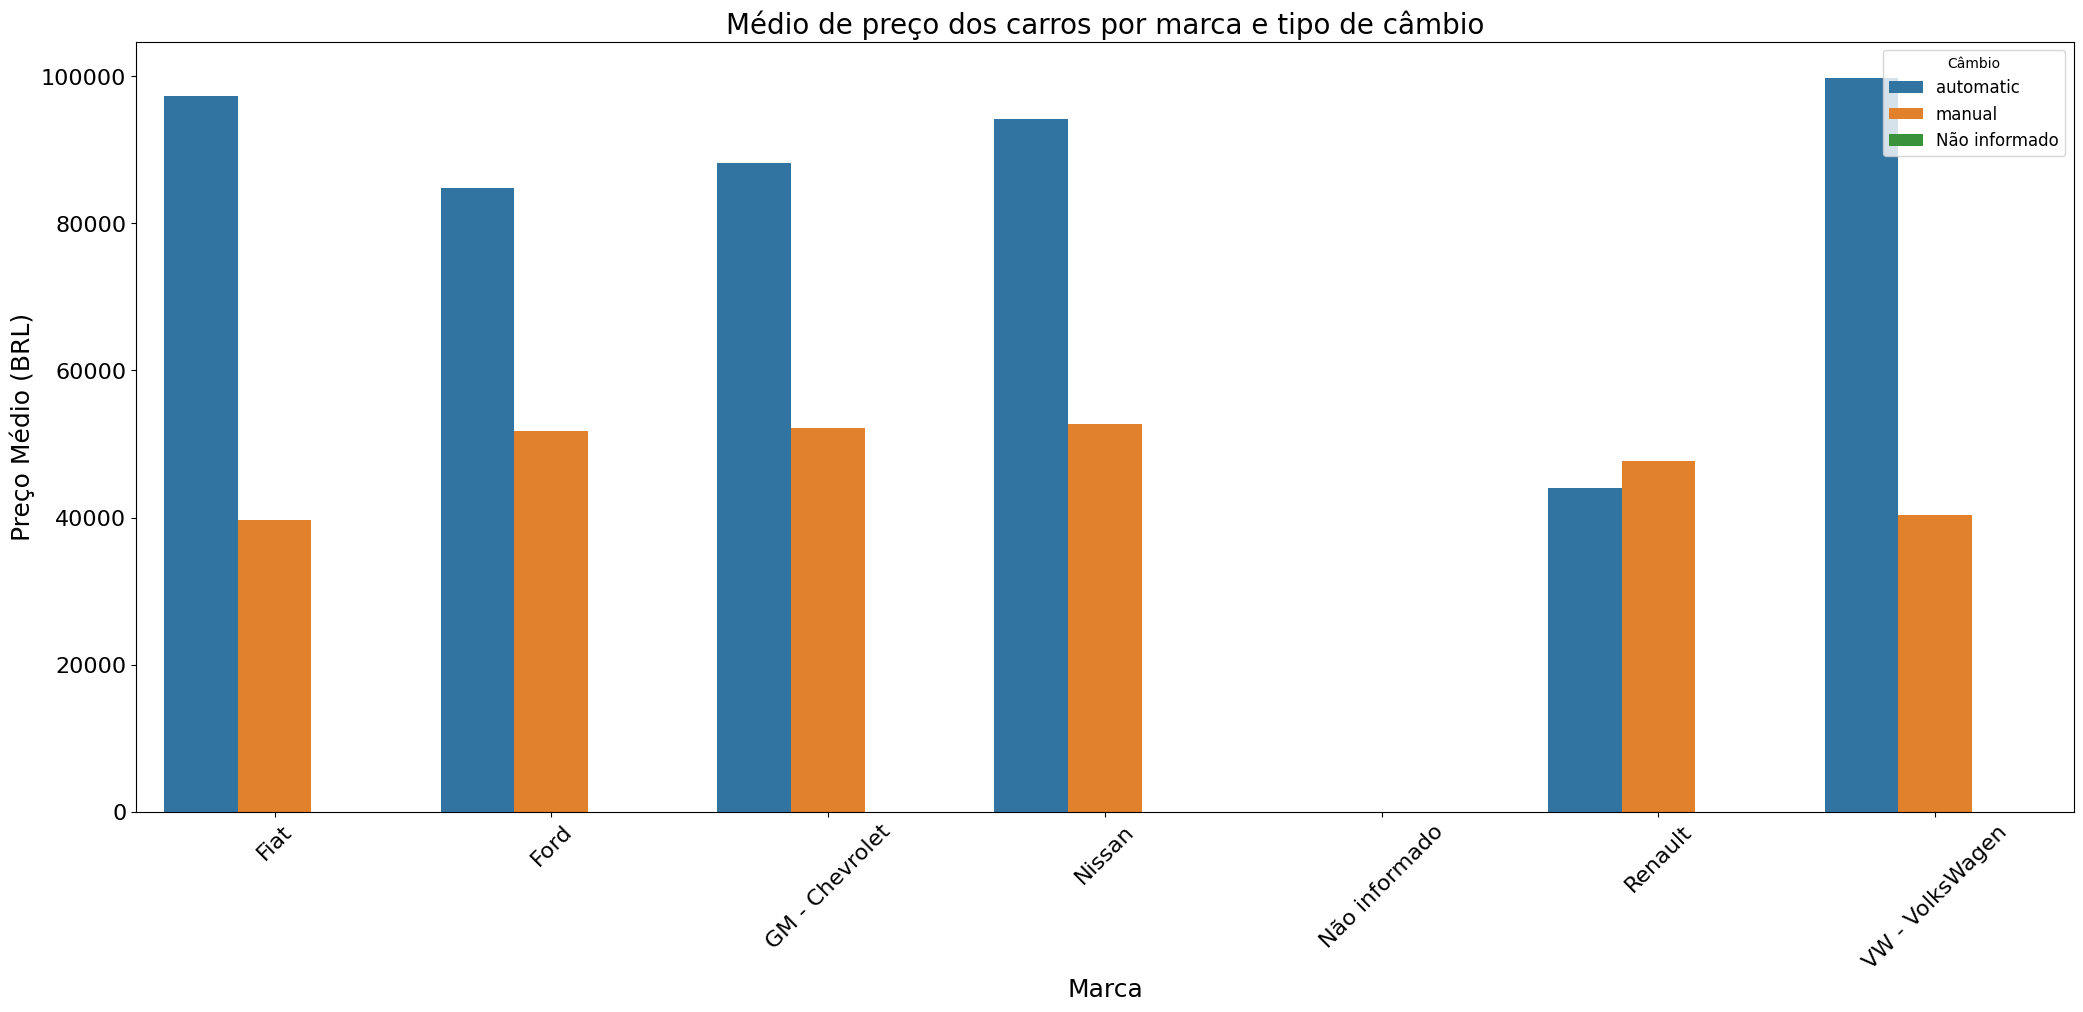

In [126]:
# Gerando o gráfio
plt.figure(figsize=(25,10))
sns.barplot(x='marca', y='preco_medio_brl', hue='cambio', data=media_preco_marca_cambio)

plt.title('Médio de preço dos carros por marca e tipo de câmbio', fontsize=20)
plt.xlabel('Marca', fontsize=18)
plt.ylabel('Preço Médio (BRL)', fontsize=18)

plt.xticks(fontsize=16, rotation=45) # roration 45 para não sobrepor os nomes das marcas
plt.yticks(fontsize=16)

plt.legend(title='Câmbio', fontsize=12)

#### e. Explicação sobre os resultados gerados no item "d"

##### O gráfico evidencia que veículos com câmbio automático possuem preço médio significativamente maior do que os de câmbio manual em quase todas as marcas. A VW - Volkswagen apresenta a maior média de preço entre os automáticos, enquanto a Renault é a única marca onde o câmbio manual tem preço médio superior ao automático. A Fiat, apesar de ser a marca mais presente na base, possui um dos menores preços médios entre os automáticos.

#### f. Gráfico da distribuição da média de preço dos carros por marca e tipo de combustível

In [127]:
# Organizando os dados
media_preco_marca_combustivel=dados.groupby(['marca', 'combustivel'])['preco_medio_brl'].mean().reset_index()

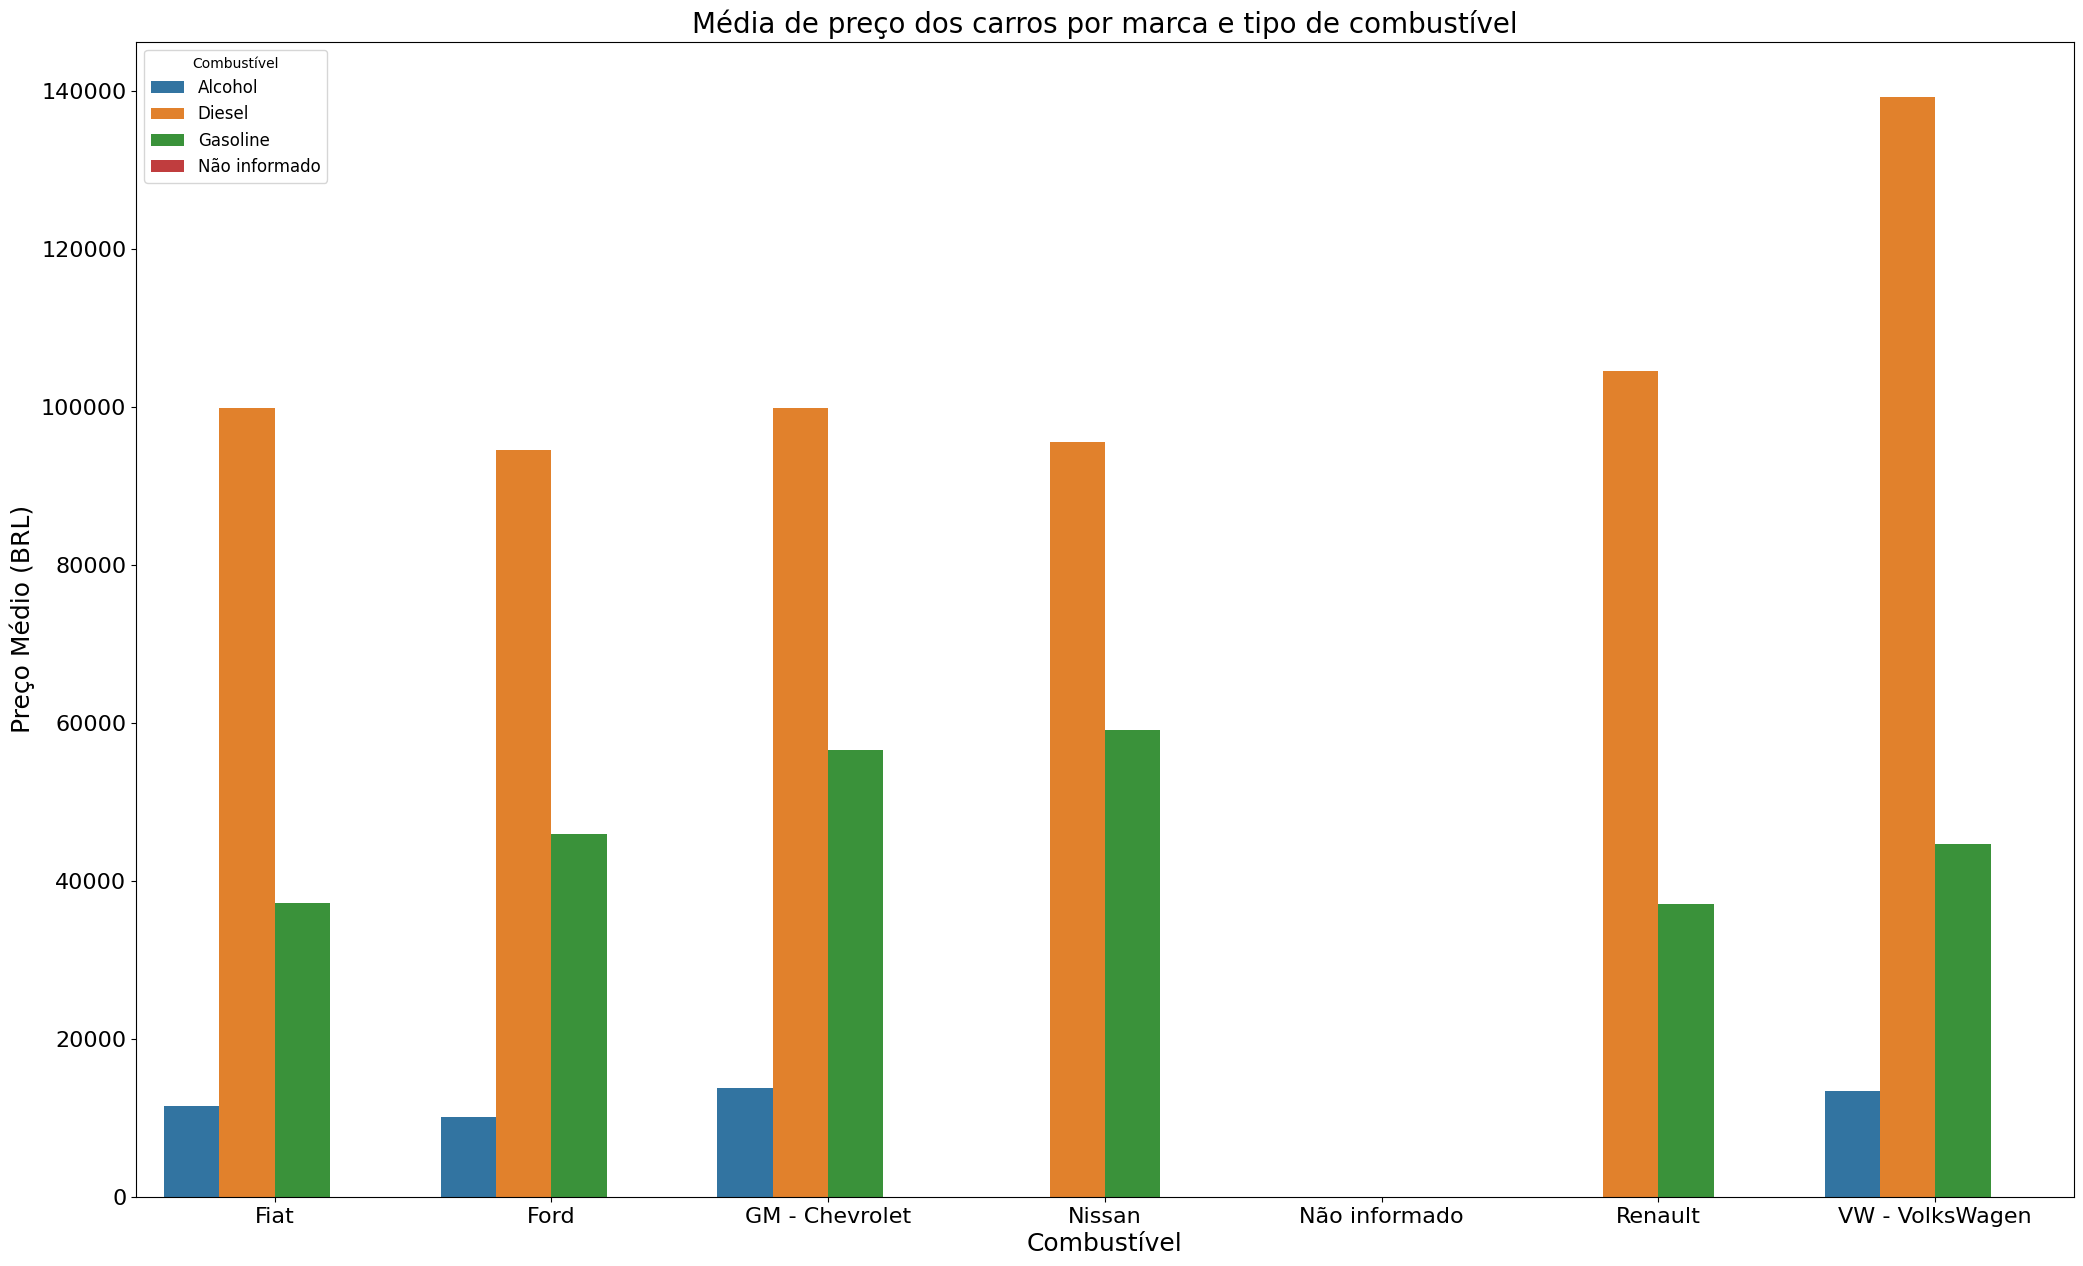

In [128]:
plt.figure(figsize=(25,15))
sns.barplot(x='marca', y='preco_medio_brl', hue='combustivel', data=media_preco_marca_combustivel)

plt.title('Média de preço dos carros por marca e tipo de combustível', fontsize=20)
plt.xlabel('Combustível', fontsize=18)
plt.ylabel('Preço Médio (BRL)', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(title='Combustível', fontsize=12)

#### g. Explicação sobre os resultados gerados no item "f"

##### O gráfico evidencia que veículos a Diesel possuem preço médio significativamente maior do que os movidos a Álcool ou Gasolina em todas as marcas. A Volkswagen se destaca com a maior média de preço entre os veículos Diesel. Nissan e Renault são as únicas marcas sem veículos a Álcool na base, e os carros a Álcool possuem o menor preço médio em todas as marcas.

---
### 3. Aplicação de modelos de Machine Learning para prever o preço médio dos carros

#### a. Variáveis numéricas (modelos de regressão)

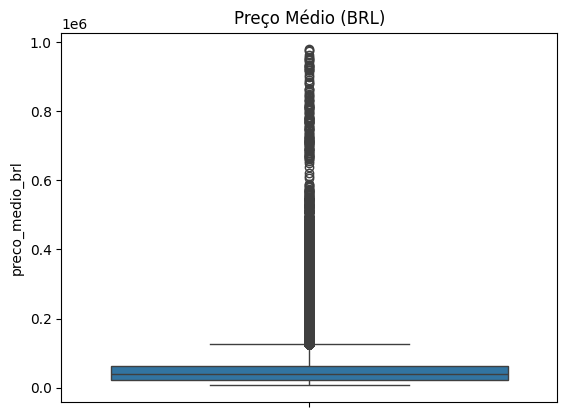

In [129]:
# Vou analisar a variável target (avg_price)
sns.boxplot(dados['preco_medio_brl']).set_title('Preço Médio (BRL)');

In [136]:
# Removendo os valores nulos do meu target
dados_modelo=dados_modelo.dropna()

# As variáveis categóricas abaixo serão transformadas
colunas_categoricas=['mes_de_referencia', 'marca', 'combustivel', 'cambio', 'tamanho_motor']

# Transformando
dados_modelo=pd.get_dummies(dados, columns=colunas_categoricas, drop_first=True)

# Definindo X e Y
# X = Variáveis independentes
# Y = Target
X=dados_modelo.drop(columns=['preco_medio_brl', 'modelo', 'codigo_fipe', 'autenticacao'])
y=dados_modelo['preco_medio_brl']

# Verificando se há valores nulos
print(f'Nulos em X: {X.isnull().sum().sum()}')
print(f'Nulos em y: {y.isnull().sum()}')

Nulos em X: 0
Nulos em y: 0


In [137]:
dados.dtypes

ano_de_referencia    float64
mes_de_referencia        str
codigo_fipe              str
autenticacao             str
marca                    str
modelo                   str
combustivel              str
cambio                   str
tamanho_motor            str
ano_modelo           float64
preco_medio_brl      float64
dtype: object

##### As variáveis numéricas ano_de_referencia e ano_modelo foram utilizadas diretamente.
##### As variáveis categóricas mes_de_referencia, marca, combustivel, cambio e tamanho_motor foram transformadas em variáveis numéricas através do método pd.get_dummies, que cria colunas binárias (0 ou 1) para cada categoria.
##### As variáveis modelo, codigo_fipe e autenticacao foram descartadas por serem identificadores ou posuir muitos valores (modelo).

#### b. Crie partições contendo 75% dos dados para treino e 25% para teste

##### Para a divisão dos dados eu optei por:
##### Conjunto de treinamento (X_train e y_train): Conjunto utilizado para trinar o modelo, 75% dos dados serão selecionados para o treinamento;
##### Conjunto de teste (X_test e y_test): Conjunto utilizado para avaliar o desempenho do modelo, 25% dos dados serão reservados para o teste

In [138]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, random_state=42)

print(f'Tamanho do treino: {X_train.shape}')
print(f'Tamanho do teste: {X_test.shape}')

Tamanho do treino: (151721, 49)
Tamanho do teste: (50574, 49)


#### c. Treinando modelo Random Forest e XGBoost

In [139]:
# Removendo os valores nulos do target
dados=dados.dropna(subset=['preco_medio_brl'])

In [140]:
# RandonForest
rf_model=RandomForestRegressor(
    n_estimators=100, #número de arvores
    max_depth=10, # profundidade máxima de cada árvore 
    random_state=42
)

rf_model.fit(X_train, y_train)
print('Random Forest treinado com sucesso!')

Random Forest treinado com sucesso!


In [141]:
# XGBoost
xgb_model=XGBRegressor(
    n_estimators=100, # número de arvores
    max_depth=6, #profundidade máxima de cada árvore
    learning_rate=0.1, # taxa de aprendizado
    random_state=42
)

xgb_model.fit(X_train, y_train)
print('XGBoost treinado com sucesso!')

XGBoost treinado com sucesso!


##### Foram treinados dois modelos: 
##### RandomForestRegressor com 100 árvores e profundidade máxima de 10; e 
##### XGBRegressor com 100 árvores, profundidade máxima 6 e learning_rate de 0.1.
##### O parâmetro random_state=42 foi utilizado em ambos para garantir reprodutibilidade.

#### d. Gravando os valores preditos em variáveis criadas

In [142]:
# Agora irei gravar os modelos preditos em variáveis
y_pred_rf=rf_model.predict(X_test)
y_pred_xgb=xgb_model.predict(X_test)

# Verificando as primeiras previsões
print('Primeiras previsões Random Forest: ', y_pred_rf[:5])
print('Primeiras previsões XGBoost: ', y_pred_xgb[:5])

Primeiras previsões Random Forest:  [41727.18693211 13793.82732514 14569.86036846 25204.28423475
 84199.86170943]
Primeiras previsões XGBoost:  [45677.27  10046.165 14563.729 27939.969 67106.77 ]


#### e. Análise de importância das variáveis, para estimar a variável Target

In [143]:
# Criando dataframe de importância para cada modelo
importancia_rf=pd.DataFrame({
    'variavel': X.columns,
    'importancia': rf_model.feature_importances_
}).sort_values('importancia', ascending=False)

importancia_xgb=pd.DataFrame({
    'variavel': X.columns,
    'importancia': xgb_model.feature_importances_
}).sort_values('importancia', ascending=False)

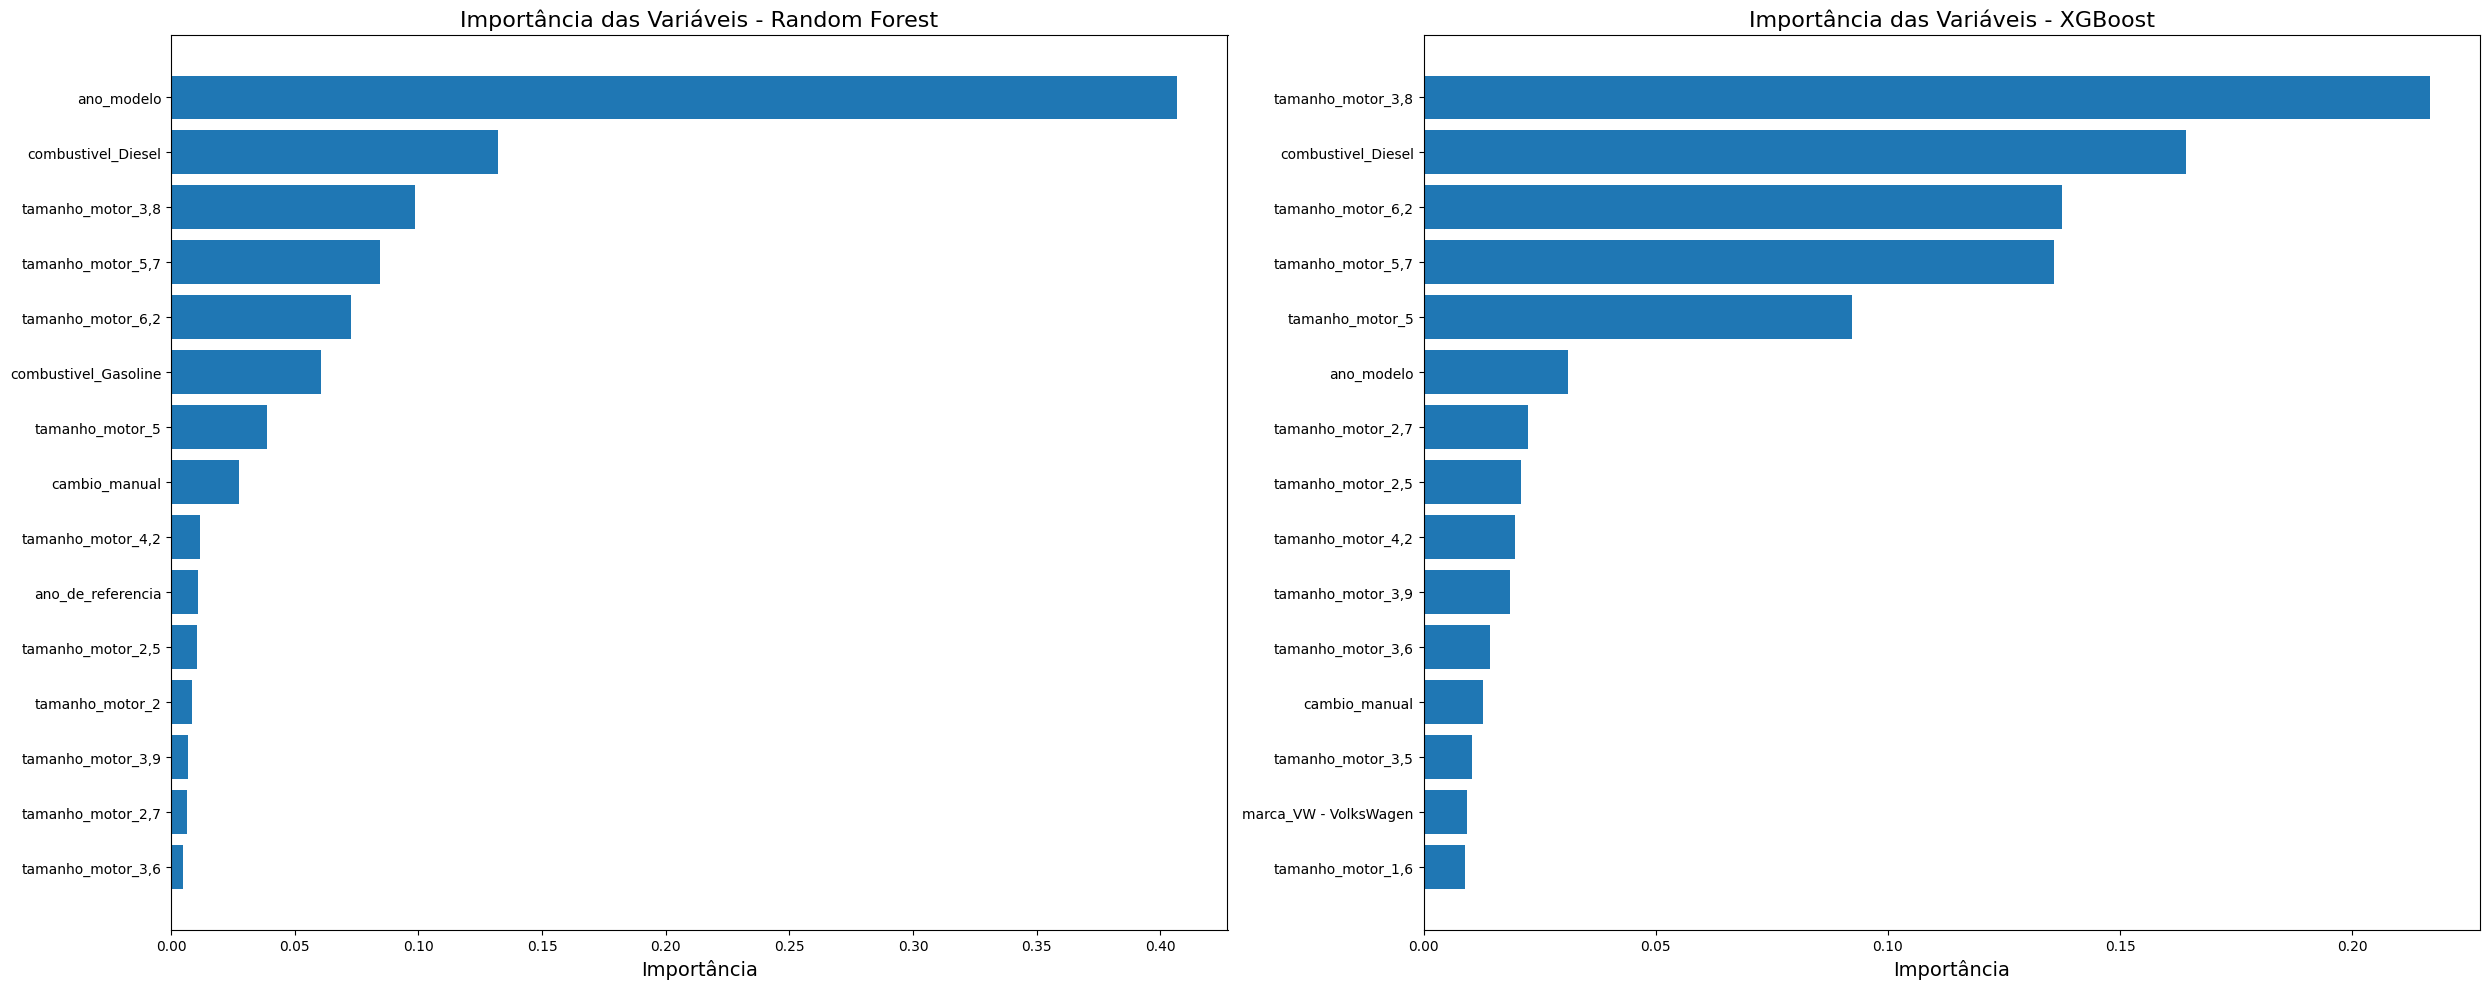

In [144]:
# Agora irei gerar gráficos para visualizar cada variável criada
fig, axes=plt.subplots(1, 2, figsize=(25,10))

# RandomForest
axes[0].barh(importancia_rf['variavel'].head(15), importancia_rf['importancia'].head(15))
axes[0].set_title('Importância das Variáveis - Random Forest', fontsize=16)
axes[0].set_xlabel('Importância', fontsize=14)
axes[0].invert_yaxis()

# XGBoost
axes[1].barh(importancia_xgb['variavel'].head(15), importancia_xgb['importancia'].head(15))
axes[1].set_title('Importância das Variáveis - XGBoost', fontsize=16)
axes[1].set_xlabel('Importância', fontsize=14)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### f. Explicação sobre os resultados encontrados na análise de importância de variáveis

##### O gráfico evidencia que para o modelo Random Forest, a variável ano_modelo é de longe a variável mais importante, o que faz muito sentido, visto que carros mais novos tendem a valer mais. Por outro lado, para o modelo XGBoost essa mesma variável passa a oculpar a 6ª colocação na importância, fato curioso e que precisa ser visto com mais calma. Os pontos em que os dois modelos concordam, é nas variáveis "combustivel_diesel" e "tamanho_motor", onde essas variáveis aparecem com alta importância nos dois modelos.

#### g. Escolha o melhor modelo com base nas métricas de avaliação: MSE, MAE e R²

In [145]:
# Métricas Random Forest
mse_rf=mean_squared_error(y_test, y_pred_rf)
mae_rf=mean_absolute_error(y_test, y_pred_rf)
r2_rf=r2_score(y_test, y_pred_rf)

# Métricas XGBoost
mse_xgb=mean_squared_error(y_test, y_pred_xgb)
mae_xgb=mean_absolute_error(y_test, y_pred_xgb)
r2_xgb=r2_score(y_test, y_pred_xgb)

# Exibindo em tabela comparativa
resultados=pd.DataFrame({
    'Métrica': ['MSE', 'MAE', 'R²'],
    'Random Forest': [mse_rf, mae_rf, r2_rf],
    "XGBoost": [mse_xgb, mae_xgb, r2_xgb]
})

print(resultados)

  Métrica  Random Forest       XGBoost
0     MSE   2.371876e+08  1.404116e+08
1     MAE   9.024246e+03  6.650331e+03
2      R²   9.118674e-01  9.478268e-01


In [147]:
# MSE: Média dos erros ao quadrado (quanto menor, melhor)
# MAE: Média dos erros absolutos, em reais (quanto menor, melhor)
# R²: O quanto o modelo explica a variação dos dados (quanto maior, melhor)

#### h. Explicação sobre qual modelo gerou o melhor resultado e a métrica de avaliação utilizada

##### Com base nas métricas de avaliação, o modelo XGBoost apresentou desempenho superior ao Random Forest nas três métricas analisadas. 
##### O R² de 0.9478 indica que o modelo explica 94,78% da variação dos preços, com um erro médio absoluto de R$6.650 por previsão.
##### Portanto, o XGBoost foi escolhido como o melhor modelo para predição dos preços dos carros.